# Improve document understanding with vision and Code Interpreter

Multimodal models are already strong at understanding documents, charts, forms, and mixed-layout images. With a few practical configuration choices, you can make outputs even more faithful on dense pages, preserve more structure in transcriptions, and give the model a richer visual workflow when you want extra inspection.

In this notebook, we'll walk through a set of reusable patterns for getting the best results from the Responses API on document and multimodal tasks:

- Increase image detail when pages contain small text or crowded layouts.
- Ask for fuller transcriptions when fidelity matters more than brevity.
- Return bounding boxes in a stable normalized format.
- Use Code Interpreter, or lightweight visual tools in restricted environments, for harder visual QA.
- Increase reasoning for chart, table, and form QA when the answer depends on multiple parts of the page.

## Prerequisites

- Python 3.10+
- `OPENAI_API_KEY` set in your environment

## Setup

Install the minimum dependencies if needed. This notebook uses four bundled example assets by default: a dense newspaper page from OmniDocBench, a police report form from CheckboxQA, a sample ECG image for a medical-vision spot check, and a sample chest X-ray for a second medical-vision check. The police form is the main working example for most patterns because it is a more practical and harder document-understanding task. Run it from the `openai-cookbook` repository root so the relative `images/...` paths resolve directly.


In [2]:
import base64
import mimetypes
import os
from pathlib import Path

from openai import OpenAI

EXAMPLE_IMAGES = {
    "newspaper": Path("images/newspaper.png"),
    "police_form": Path("images/police_form.png"),
    "ecg": Path("images/ecg.jpg"),
    "cxr": Path("images/CXR.jpeg"),
}

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY before running this notebook.")

client = OpenAI(api_key=OPENAI_API_KEY)


def require_example_image(name: str) -> Path:
    path = EXAMPLE_IMAGES[name]
    if not path.exists():
        raise FileNotFoundError(f"Example image not found: {path}")
    return path


def example_image_data_url(name: str) -> str:
    path = require_example_image(name)
    mime_type = mimetypes.guess_type(path.name)[0] or "image/png"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"


print({
    "has_openai_api_key": bool(OPENAI_API_KEY),
    "newspaper_image": str(require_example_image("newspaper")),
    "police_form_image": str(require_example_image("police_form")),
    "ecg_image": str(require_example_image("ecg")),
    "cxr_image": str(require_example_image("cxr")),
})


{'has_openai_api_key': True, 'newspaper_image': 'images/newspaper.png', 'police_form_image': 'images/police_form.png', 'ecg_image': 'images/ecg.jpg', 'cxr_image': 'images/CXR.jpeg'}


## Pattern 1: Raise image detail for dense documents

For tasks where high-resolution vision matters, such as computer use, handwriting, dense forms, and chart QA, increase the image `detail` setting.

Start with `auto` for general use, move to `high` when the page is dense or the model is missing small text, and use `original` when you want the highest-fidelity pass.

`original` is the maximum-resolution option: it does not resize the image before processing. That makes it the clearest choice for very dense documents, small labels, or screenshots where preserving the original pixels matters.

The best detail setting can also be model-dependent. In selected dense-document comparisons, GPT-5.2 and GPT-5.4 were roughly comparable at default detail, but when detail was increased to `original`, GPT-5.4 improved on the densest documents.

Use this pattern for:

- dense OCR
- handwritten notes
- forms with small labels
- chart labels
- mixed text-and-image layouts


![OmniDocBench Selected Runs](../../images/omnidocbench_selected_runs.png)


## Pattern 2: Turn verbosity high when transcription matters

If you want the transcription to stay exact instead of compact, set `text={"verbosity": "high"}`. Multimodal models can often preserve the meaning of a page while representing it with fewer tokens, which means tables and structured layouts may come back in a slightly compressed form even when the content is mostly correct.

Higher verbosity nudges the model toward a more literal rendering of the page. In table-heavy evaluations, we've seen roughly `3–7%` better table-structure fidelity on edit-distance style metrics because the model is more likely to preserve the original table layout instead of rewriting it into a shorter format. On very dense documents, it can also reduce early stopping and over-summarization, improving completeness by roughly `4–5%` and text edit distance by about `5%`. The police form below is a good stress case because it contains repeated field groups, checkbox clusters, and table-like structure.

Use `text={"verbosity": "high"}` when:

- you need layout-faithful markdown instead of a compact rewrite
- table structure matters as much as the text itself
- very dense documents are getting summarized or cut short
- you are benchmarking transcription fidelity across models or settings

![](images/newspaper.png)


In [3]:
newspaper_image_url = example_image_data_url("newspaper")

verbose_response = client.responses.create(
    model="galapagos-alpha",
    text={"verbosity": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": (
                        "Transcribe the section about Mikiya Wagyu Shabu House."
                    ),
                },
                {
                    "type": "input_image",
                    "image_url": newspaper_image_url,
                    "detail": "high",
                },
            ],
        }
    ],
)
print(verbose_response.output_text)


Here is the section about **Mikiya Wagyu Shabu House** as it appears in the image:

**Mikiya Wagyu Shabu House**

If you’re starving, cold, and enjoy wagyu beef, Mikiya is calling you. This Chinatown restaurant serves all-you-can-eat wagyu hot pot at a variety of price points; you have 90 minutes to cook a variety of cuts in the broths of your choosing, while eating specialty dishes such as sweet shrimp sashimi and wagyu bone marrow, plus fruit and ice cream for dessert. Mikiya is a project from Chubby Group, whose Kevin Liu is also behind Matsunori Handroll Bar.

*Wagyu sets $45-$98 (less with annual membership); free or half-price for kids.*


## Pattern 3: Ask for bounding boxes in a stable format

For localization tasks, use a consistent box format like `[x_min, y_min, x_max, y_max]`. A practical convention is to request discrete normalized coordinates between `0` and `999`, with `(0, 0)` at the top-left corner.

This format is easy to post-process for:

- cropping regions
- drawing overlays
- building review tools
- routing specific page regions into downstream OCR or extraction pipelines

![](images/police_form.png)


In [4]:
import json

bbox_prompt = """
Find the vehicle travel direction and damaged area codes for Vehicles 1 and 2 in the police report form.

Return JSON with this schema:
[
  {\"label\": \"vehicle_1_travel_direction\", "bbox": [x_min, y_min, x_max, y_max]},
  {\"label\": \"vehicle_1_damaged_area_code\", "bbox": [x_min, y_min, x_max, y_max]},
  {\"label\": \"vehicle_2_travel_direction\", "bbox": [x_min, y_min, x_max, y_max]},
  {\"label\": \"vehicle_2_damaged_area_code\",  "bbox": [x_min, y_min, x_max, y_max]}
]

Use discrete normalized coordinates between 0 and 999.
"""

police_form_image_url = example_image_data_url("police_form")

bbox_response = client.responses.create(
    model="galapagos-alpha",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": bbox_prompt},
                {
                    "type": "input_image",
                    "image_url": police_form_image_url,
                    "detail": "high",
                },
            ],
        }
    ],
)
results = json.loads(bbox_response.output_text)
print(json.dumps(results, indent=2))


[
  {
    "label": "vehicle_1_travel_direction",
    "bbox": [
      122,
      509,
      218,
      527
    ]
  },
  {
    "label": "vehicle_1_damaged_area_code",
    "bbox": [
      663,
      457,
      764,
      552
    ]
  },
  {
    "label": "vehicle_2_travel_direction",
    "bbox": [
      212,
      803,
      307,
      822
    ]
  },
  {
    "label": "vehicle_2_damaged_area_code",
    "bbox": [
      661,
      751,
      764,
      847
    ]
  }
]


### Preview and Compare This Bounding-Box Example

Use the next three cells to:

1. load the saved Pattern 3 bounding-box output,
2. render the boxes on the police form, and
3. compare the same prompt with Code Interpreter enabled.


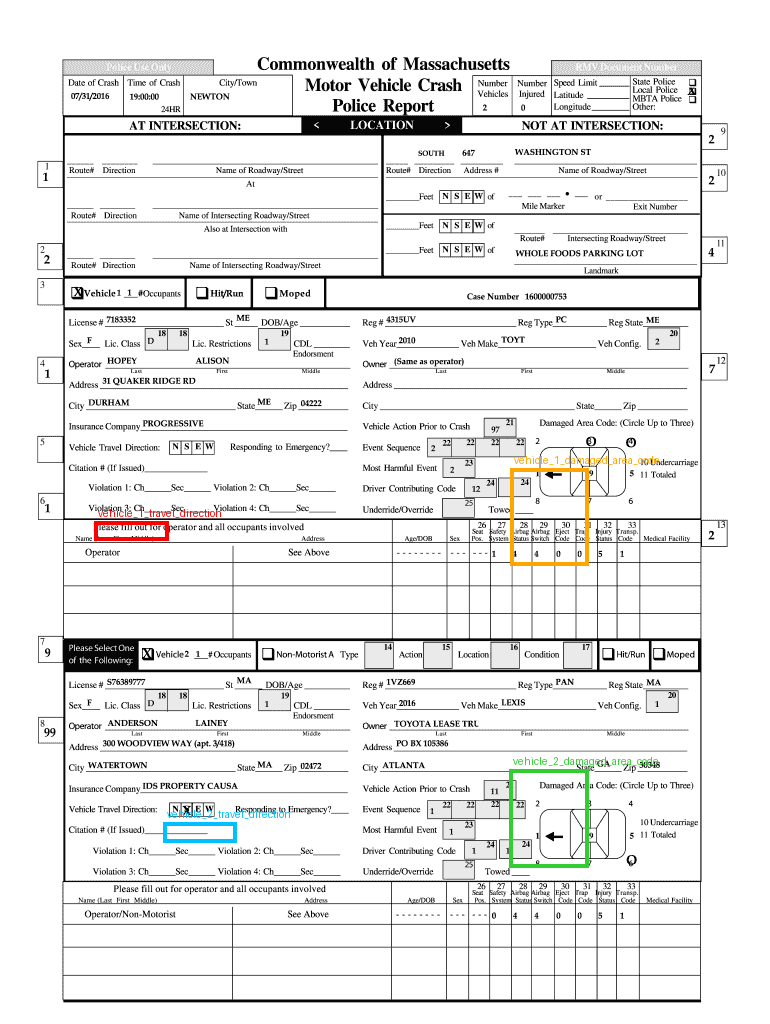

[
  {
    "label": "vehicle_1_travel_direction",
    "bbox": [
      94,
      521,
      168,
      540
    ]
  },
  {
    "label": "vehicle_1_damaged_area_code",
    "bbox": [
      510,
      468,
      588,
      565
    ]
  },
  {
    "label": "vehicle_2_travel_direction",
    "bbox": [
      163,
      822,
      236,
      842
    ]
  },
  {
    "label": "vehicle_2_damaged_area_code",
    "bbox": [
      509,
      769,
      588,
      867
    ]
  }
]


In [5]:
import json
from IPython.display import display
from PIL import Image, ImageDraw


def denormalize_bbox(bbox, width, height):
    x_min, y_min, x_max, y_max = bbox
    return [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]


label_colors = {
    "vehicle_1_travel_direction": "red",
    "vehicle_1_damaged_area_code": "orange",
    "vehicle_2_travel_direction": "deepskyblue",
    "vehicle_2_damaged_area_code": "limegreen",
}

annotated_image = Image.open(require_example_image("police_form")).convert("RGB")
width, height = annotated_image.size
draw = ImageDraw.Draw(annotated_image)

pixel_results = []
for item in results:
    label = item["label"]
    pixel_bbox = denormalize_bbox(item["bbox"], width, height)
    pixel_results.append({"label": label, "bbox": pixel_bbox})

    color = label_colors.get(label, "yellow")
    draw.rectangle(pixel_bbox, outline=color, width=4)
    draw.text((pixel_bbox[0] + 4, max(0, pixel_bbox[1] - 14)), label, fill=color)

display(annotated_image)
print(json.dumps(pixel_results, indent=2))


In [11]:
import json

bbox_prompt_for_ci = globals().get(
    "bbox_prompt",
    """
Find the vehicle travel direction and damaged area codes for Vehicles 1 and 2 in the police report form.

Return JSON with this schema:
[
  {\"label\": \"vehicle_1_travel_direction\", \"bbox\": [x_min, y_min, x_max, y_max]},
  {\"label\": \"vehicle_1_damaged_area_code\", \"bbox\": [x_min, y_min, x_max, y_max]},
  {\"label\": \"vehicle_2_travel_direction\", \"bbox\": [x_min, y_min, x_max, y_max]},
  {\"label\": \"vehicle_2_damaged_area_code\", \"bbox\": [x_min, y_min, x_max, y_max]}
]

Use discrete normalized coordinates between 0 and 999.
""",
)

bbox_ci_instructions = globals().get(
    "instructions",
    """
You are an expert document analyst.

You must use Code Interpreter at least once before answering.
Inspect the uploaded file in the container, and crop or zoom if needed.
Do not answer from the raw image alone.
""",
)

comparison_image_url = example_image_data_url("police_form")
comparison_asset = require_example_image("police_form")

with comparison_asset.open("rb") as asset_file:
    bbox_visual_file = client.files.create(file=asset_file, purpose="user_data")

bbox_ci_response = client.responses.create(
    model="galapagos-alpha",
    instructions=bbox_ci_instructions,
    tools=[
        {
            "type": "code_interpreter",
            "container": {
                "type": "auto",
                "memory_limit": "4g",
                "file_ids": [bbox_visual_file.id],
            },
        }
    ],
    include=["code_interpreter_call.outputs"],
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": (
                        "Use Code Interpreter to inspect the uploaded police report form before answering. "
                        "You must use the tool at least once.\n\n"
                        f"{bbox_prompt_for_ci.strip()}"
                    ),
                },
                {
                    "type": "input_image",
                    "image_url": comparison_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)

def response_item_type(item):
    if isinstance(item, dict):
        return item.get("type")
    return getattr(item, "type", None)


bbox_ci_calls = [
    item for item in (bbox_ci_response.output or []) if response_item_type(item) == "code_interpreter_call"
]
bbox_ci_used = bool(bbox_ci_calls)

print(f"Code Interpreter invoked: {bbox_ci_used}")
print(f"Code Interpreter call count: {len(bbox_ci_calls)}")
print("\nBaseline result:")
print(json.dumps(results, indent=2))

try:
    bbox_results_with_ci = json.loads(bbox_ci_response.output_text)
    print("\nWith Code Interpreter:")
    print(json.dumps(bbox_results_with_ci, indent=2))
    print(f"\nMatches baseline: {bbox_results_with_ci == results}")
except json.JSONDecodeError:
    bbox_results_with_ci = None
    print("\nWith Code Interpreter (raw output):")
    print(bbox_ci_response.output_text)


Code Interpreter invoked: True
Code Interpreter call count: 5

Baseline result:
[
  {
    "label": "vehicle_1_travel_direction",
    "bbox": [
      122,
      509,
      218,
      527
    ]
  },
  {
    "label": "vehicle_1_damaged_area_code",
    "bbox": [
      663,
      457,
      764,
      552
    ]
  },
  {
    "label": "vehicle_2_travel_direction",
    "bbox": [
      212,
      803,
      307,
      822
    ]
  },
  {
    "label": "vehicle_2_damaged_area_code",
    "bbox": [
      661,
      751,
      764,
      847
    ]
  }
]

With Code Interpreter:
[
  {
    "label": "vehicle_1_travel_direction",
    "bbox": [
      221,
      430,
      273,
      446
    ]
  },
  {
    "label": "vehicle_1_damaged_area_code",
    "bbox": [
      753,
      423,
      777,
      444
    ]
  },
  {
    "label": "vehicle_2_travel_direction",
    "bbox": [
      221,
      783,
      273,
      799
    ]
  },
  {
    "label": "vehicle_2_damaged_area_code",
    "bbox": [
      807,
      835,

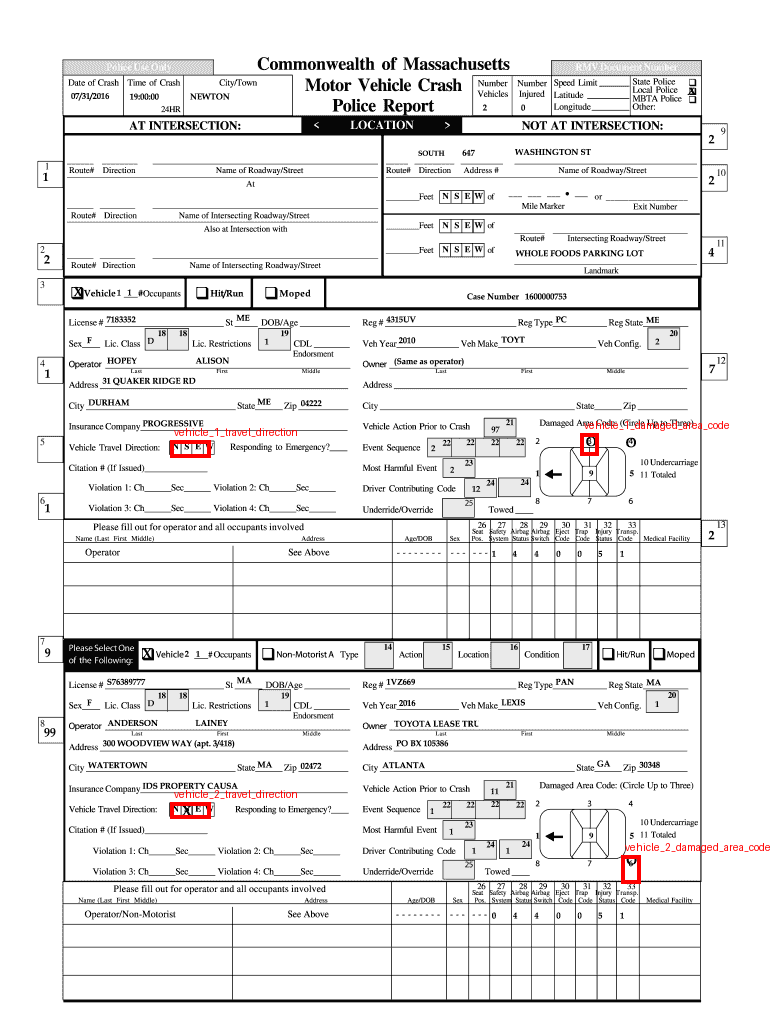

[
  {
    "label": "vehicle_1_travel_direction",
    "bbox": [
      221,
      430,
      273,
      446
    ]
  },
  {
    "label": "vehicle_1_damaged_area_code",
    "bbox": [
      753,
      423,
      777,
      444
    ]
  },
  {
    "label": "vehicle_2_travel_direction",
    "bbox": [
      221,
      783,
      273,
      799
    ]
  },
  {
    "label": "vehicle_2_damaged_area_code",
    "bbox": [
      807,
      835,
      831,
      862
    ]
  }
]


In [12]:
bbox_results_with_ci = json.loads(bbox_ci_response.output_text)
results_to_visualize = bbox_results_with_ci if bbox_results_with_ci is not None else results

annotated_image = Image.open(require_example_image("police_form")).convert("RGB")
width, height = annotated_image.size
draw = ImageDraw.Draw(annotated_image)

for item in results_to_visualize:
    pixel_bbox = denormalize_bbox(item["bbox"], width, height)
    draw.rectangle(pixel_bbox, outline="red", width=4)
    draw.text((pixel_bbox[0] + 4, max(0, pixel_bbox[1] - 14)), item["label"], fill="red")

display(annotated_image)
print(json.dumps(results_to_visualize, indent=2))

## Pattern 4: Use Code Interpreter for hard visual QA

Some visual tasks benefit from more than one pass over the input. Code Interpreter helps because the model can crop, zoom, rotate, and inspect the file programmatically before answering.

This is useful for:

- charts with tiny labels
- skewed or rotated scans
- documents with hard-to-read footnotes
- mixed-layout pages where the answer depends on multiple regions

In the example below, the model works over the police form and has to recover the vehicle travel direction plus damaged area codes for Vehicles 1 and 2. The notebook uses a local file upload so the same asset can be provided both as a model input and as a Code Interpreter container file.

![](images/police_form.png)


In [27]:
instructions = """
You are an expert document analyst.

For hard visual questions, zoom, crop, rotate, or inspect intermediate regions. Do not attempt to guess any values until you have inspected the image closely
"""

visual_asset = require_example_image("police_form")
visual_image_url = example_image_data_url("police_form")

with visual_asset.open("rb") as asset_file:
    visual_file = client.files.create(file=asset_file, purpose="user_data")

ci_response = client.responses.create(
    model="galapagos-alpha",
    instructions=instructions,
    tools=[
        {
            "type": "code_interpreter",
            "container": {
                "type": "auto",
                "memory_limit": "4g",
                "file_ids": [visual_file.id],
            },
        }
    ],
    include=["code_interpreter_call.outputs"],
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": (
                        "Read the attached police report form carefully. What were the "
                        "damaged area codes for Vehicles 1? They are marked by a CIRCLE around the number. " 
                        "There could be multiple (up to three). Cite the field labels or regions you used."
                    ),
                },
                {"type": "input_image", "image_url": visual_image_url, "detail": "original"},
            ],
        }
    ],
)

print(ci_response.output_text)


For Vehicle 1, the circled damaged area codes are **3** and **4**.

I used the **“Damaged Area Code: (Circle Up to Three)”** field in the **Vehicle 1** section, specifically the vehicle damage diagram where the circled numbers appear above the car outline.


## If you cannot use Code Interpreter, expose lightweight visual tools

In zero-data-retention or self-hosted environments, you may not want to give the model a general Python sandbox. In those cases, we recommend setting up either:

1. **your own sandboxed Python execution environment**, or
2. **a small set of visual tools the agent can call directly like**:

- `crop_image`
- `zoom_image`
- `rotate_image`
- `ocr_region` (optional)

This is often cheaper and more controllable than unrestricted code execution while still giving the model a multi-pass visual workflow.

### Example: Agents SDK with custom visual tool

![](images/chart.png)


In [28]:
import uuid
from dataclasses import dataclass
from pathlib import Path
from PIL import Image


@dataclass
class StoredImage:
    image_id: str
    path: Path
    width: int
    height: int


class LocalImageStore:
    def __init__(self, root_dir: str = "./image_store"):
        self.root = Path(root_dir)
        self.root.mkdir(parents=True, exist_ok=True)

    def _new_image_path(self) -> tuple[str, Path]:
        image_id = f"img_{uuid.uuid4().hex}"
        path = self.root / f"{image_id}.png"
        return image_id, path

    def add_image(self, source_path: str) -> str:
        image_id, out_path = self._new_image_path()
        with Image.open(source_path) as img:
            img.save(out_path, format="PNG")
        return image_id

    def get_path(self, image_id: str) -> Path:
        path = self.root / f"{image_id}.png"
        if not path.exists():
            raise FileNotFoundError(f"Unknown image_id: {image_id}")
        return path

    def metadata(self, image_id: str) -> StoredImage:
        path = self.get_path(image_id)
        with Image.open(path) as img:
            width, height = img.size
        return StoredImage(
            image_id=image_id,
            path=path,
            width=width,
            height=height,
        )

    def crop(
        self,
        image_id: str,
        x_min: int,
        y_min: int,
        x_max: int,
        y_max: int,
    ) -> str:
        src_path = self.get_path(image_id)
        new_image_id, out_path = self._new_image_path()

        with Image.open(src_path) as img:
            cropped = img.crop((x_min, y_min, x_max, y_max))
            cropped.save(out_path, format="PNG")

        return new_image_id

    def rotate(
        self,
        image_id: str,
        degrees: float,
    ) -> str:
        src_path = self.get_path(image_id)
        new_image_id, out_path = self._new_image_path()

        with Image.open(src_path) as img:
            rotated = img.rotate(degrees, expand=True)
            rotated.save(out_path, format="PNG")

        return new_image_id

    def zoom(
        self,
        image_id: str,
        factor: float,
    ) -> str:
        if factor <= 0:
            raise ValueError("factor must be > 0")

        src_path = self.get_path(image_id)
        new_image_id, out_path = self._new_image_path()

        with Image.open(src_path) as img:
            width, height = img.size
            resized = img.resize(
                (int(width * factor), int(height * factor)),
                resample=Image.Resampling.LANCZOS,
            )
            resized.save(out_path, format="PNG")

        return new_image_id

In [31]:
from dataclasses import dataclass
from agents import Agent, Runner, RunContextWrapper, function_tool


@dataclass
class ImageRuntimeContext:
    image_store: LocalImageStore


@function_tool
def crop_image(
    ctx: RunContextWrapper[ImageRuntimeContext],
    image_id: str,
    x_min: int,
    y_min: int,
    x_max: int,
    y_max: int,
) -> str:
    return ctx.context.image_store.crop(image_id, x_min, y_min, x_max, y_max)


@function_tool
def rotate_image(
    ctx: RunContextWrapper[ImageRuntimeContext],
    image_id: str,
    degrees: float,
) -> str:
    return ctx.context.image_store.rotate(image_id, degrees)


@function_tool
def zoom_image(
    ctx: RunContextWrapper[ImageRuntimeContext],
    image_id: str,
    factor: float,
) -> str:
    return ctx.context.image_store.zoom(image_id, factor)


agent = Agent[ImageRuntimeContext](
    name="Document QA Agent",
    model="galapagos-alpha",
    instructions="""
You are an expert document and image analyst.

Prefer direct visual reasoning first.
For dense or ambiguous regions, use crop, zoom, and rotate tools as needed.
Always explain what visual evidence you used before giving the final answer.
""",
    tools=[crop_image, rotate_image, zoom_image],
)

In [ ]:
import asyncio


async def main():
    image_store = LocalImageStore("./image_store")
    image_id = image_store.add_image("./images/chart.png")

    context = ImageRuntimeContext(image_store=image_store)

    result = await Runner.run(
        agent,
        f"""
        Analyze image_id="{image_id}".

        Question:
        What is the largest drop between adjacent quarters in this chart?

        Use crop, zoom, or rotate if needed before answering.
        """,
        context=context,
    )

    print(result.final_output)


# In notebooks, use top-level await instead of asyncio.run().
# If you move this into a standalone Python script, use:
# if __name__ == "__main__":
#     asyncio.run(main())
await main()

## Pattern 5: Increase reasoning for chart, table, and form QA even without tools

Some multimodal tasks still improve if you increase reasoning effort, even when the model only sees the original image once. This is most useful when the answer depends on combining evidence across multiple regions of the page.

The example below uses the same police form as the Code Interpreter example, but relies only on native vision plus higher reasoning effort.

Reasoning tends to help more for:

- chart QA with small labels or multiple series
- table QA that requires connecting values across rows or columns
- menus, forms, and financial documents with table-like structure
- mixed-layout pages where the answer depends on several regions

Reasoning tends to help less for:

- pure transcription
- simple retrieval such as "what does paragraph X say?"
- needle-in-a-haystack lookups on otherwise readable pages

The tradeoff is higher token usage, so raise reasoning selectively.

![](images/police_form.png)


In [ ]:
reasoning_only_prompt = """
Answer the question about the police report form.

Question: What was the vehicle travel direction and damaged area code for Vehicle 2?

The codes are marked by a CIRCLE around the number. There could be multiple (up to three).
Do not attempt to guess any values until you have inspected the image closely.
Return JSON with keys vehicle_2_travel_direction, and vehicle_2_damaged_area_code.
Cite the field labels or regions that support your answer.
"""

police_form_image_url = example_image_data_url("police_form")

reasoning_response = client.responses.create(
    model="galapagos-alpha",
    reasoning={"effort": "high"},
    text={"verbosity": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": reasoning_only_prompt},
                {
                    "type": "input_image",
                    "image_url": police_form_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
print(reasoning_response.output_text)


### Additional Example: ECG diagnosis with higher reasoning

![](images/ecg.jpg)


In [13]:
ecg_prompt = """A 26-year-old otherwise healthy man presents to the emergency department with a 3- to 4-hour history of left-sided chest pain. The pain is pleuritic and accompanied by nausea and discomfort in the left arm. The patient denies dyspnea, diaphoresis, fever, chills, headache, diarrhea, leg swelling, and myalgia. There is no recent history of upper respiratory tract infection, contact with ill persons, or trauma. What is the most likely dx given the EKG attached?"""

ecg_image_url = example_image_data_url("ecg")
expected_ecg_diagnosis = "acute pericarditis"

ecg_response = client.responses.create(
    model="galapagos-alpha",
    reasoning={"effort": "high"},
    text={"verbosity": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": ecg_prompt},
                {
                    "type": "input_image",
                    "image_url": ecg_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)

print(ecg_response.output_text)
print("\nMatches expected diagnosis:", expected_ecg_diagnosis in ecg_response.output_text.lower())


The ECG is most consistent with **acute pericarditis**, specifically **stage I pericarditis**.

Why this fits:
- **Pleuritic chest pain** in a young man is classic for pericarditis
- ECG appears to show **diffuse, concave ST-segment elevation**
- There are **no clear reciprocal ischemic changes** to suggest STEMI
- The pattern can resemble **benign early repolarization**, but in the setting of acute pleuritic chest pain, **pericarditis is more likely**

So the best answer is:

**Acute pericarditis**  
with **benign early repolarization** as the main ECG mimic in the differential.

Matches expected diagnosis: True


### Additional Example: CXR diagnosis with higher reasoning

![](images/CXR.jpeg)


In [14]:
cxr_prompt = "Analyze CXR and provide the most likely diagnosis"

cxr_image_url = example_image_data_url("cxr")
expected_cxr_diagnosis = "pneumothorax"

cxr_response = client.responses.create(
    model="galapagos-alpha",
    reasoning={"effort": "high"},
    text={"verbosity": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": cxr_prompt},
                {
                    "type": "input_image",
                    "image_url": cxr_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)

print(cxr_response.output_text)
print("\nMatches expected diagnosis:", expected_cxr_diagnosis in cxr_response.output_text.lower())


Most likely diagnosis: **mild hyperinflation / air trapping consistent with reactive airways disease (asthma).**

### Why
- Lungs appear **mildly overexpanded**
- No focal air-space opacity to suggest **pneumonia**
- No pleural effusion or obvious **pneumothorax**
- Cardiomediastinal silhouette is not enlarged

### Impression
**No acute cardiopulmonary abnormality; mild hyperinflation most compatible with asthma/reactive airways disease.**

If you want, I can also provide this in formal radiology report style.

Matches expected diagnosis: True


## To Do: Compare models on the same Code Interpreter task

The easiest way to compare model behavior is to keep the prompt, asset, and tool configuration fixed. The example below uses the bundled police form. Then collect:

- the final answer
- whether the model actually used crop, zoom, or rotate behavior
- token usage
- qualitative failure modes

For GPT-5 series models, this notebook sets `text={"verbosity": "high"}` to encourage more faithful, inspectable outputs.

![](images/police_form.png)


In [ ]:
MODEL_MATRIX = [
    "gpt-4o",
    "gpt-5",
    "gpt-5.4",  # Placeholder: replace with the launch-approved slug before public release.
]

comparison_prompt = """
Read the attached police report form carefully and answer the question below.

Question:
What was the vehicle travel direction and damaged area code for Vehicles 1 and 2?

Requirements:
- Use Code Interpreter if it helps.
- If the form fields are hard to read, zoom or crop before answering.
- Return JSON with keys vehicle_1_travel_direction, vehicle_1_damaged_area_code, vehicle_2_travel_direction, and vehicle_2_damaged_area_code.
- State the evidence you used.
"""

visual_asset = require_example_image("police_form")

with visual_asset.open("rb") as asset_file:
    visual_file = client.files.create(
        file=asset_file,
        purpose="user_data",
    )

results = {}
for model in MODEL_MATRIX:
    request = {
        "model": model,
        "instructions": instructions,
        "tools": [
            {
                "type": "code_interpreter",
                "container": {
                    "type": "auto",
                    "memory_limit": "4g",
                    "file_ids": [visual_file.id],
                },
            }
        ],
        "include": ["code_interpreter_call.outputs"],
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": comparison_prompt},
                    {"type": "input_image", "image_url": visual_image_url, "detail": "high"},
                ],
            }
        ],
    }

    if model.startswith("gpt-5"):
        request["text"] = {"verbosity": "high"}

    response = client.responses.create(**request)
    results[model] = {
        "response_id": response.id,
        "output_text": response.output_text,
        "usage": response.usage.model_dump() if response.usage else None,
    }

results


## Placeholder: output comparison section

Replace this section with real excerpts before publishing.

| Model | Output excerpt | Tool behavior | Notes |
|---|---|---|---|
| `gpt-4o` | `[PASTE OUTPUT EXCERPT]` | `[Did it crop, zoom, or rotate?]` | `[Strengths, misses, or ambiguities]` |
| `gpt-5` | `[PASTE OUTPUT EXCERPT]` | `[Did it crop, zoom, or rotate?]` | `[Strengths, misses, or ambiguities]` |
| `gpt-5.4` | `[PASTE OUTPUT EXCERPT]` | `[Did it crop, zoom, or rotate?]` | `[Strengths, misses, or ambiguities]` |

## Placeholder: screenshot or crop comparison section

Replace this section with the exact artifacts you want to show in the final cookbook page.

- `[INSERT IMAGE: original police report form]`
- `[INSERT IMAGE: gpt-4o intermediate crop or notable failure case]`
- `[INSERT IMAGE: gpt-5 intermediate crop or notable success case]`
- `[INSERT IMAGE: gpt-5.4 intermediate crop or notable success case]`


## Best Practices

Start with native vision when:

- the question is simple
- the page is not especially dense
- you care most about speed and cost

Add Code Interpreter when:

- the model needs multiple inspections
- the page is small, rotated, or cluttered
- you want the model to verify a reading instead of relying on one pass
- qualitative accuracy matters more than minimal token usage

Increase reasoning, even without Python, when:

- the answer depends on multiple regions of a chart, table, or form
- the task is analytical rather than pure transcription
- you can afford extra reasoning tokens for higher confidence

Expose lightweight visual tools instead of Code Interpreter when:

- you are operating in a restricted or self-hosted environment
- you want tighter control over what image transformations are allowed
- you only need crop, zoom, rotate, or an optional OCR-region fallback
